# Imja Lake moraine dam cumulative displacement time series data exploration
Quinn Brencher

In [1]:
import xarray as xr
import rasterio as rio
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np
sns.set_theme()

## Load polygon data

In [2]:
# define variables
asc_burst = '012_023790_IW1' # burst ID
des_burst = '121_258661_IW2'
dam_name = 'imja'
crs = 32645

In [4]:
## load polygons 

# read in dam polygon
dam_fn = f'../mapping/polygons/{dam_name}_md.shp'
dam_gdf = gpd.read_file(dam_fn)

# read in moving area polygon
moving_fn = f'../mapping/polygons/{dam_name}_moving.shp'
moving_gdf = gpd.read_file(moving_fn)

# read in reference area polygon
reference_fn = f'../mapping/polygons/{dam_name}_reference.shp'
reference_gdf = gpd.read_file(reference_fn)

# read in stable area polygon
stable_fn = f'../mapping/polygons/{dam_name}_stable.shp'
stable_gdf = gpd.read_file(stable_fn)

# read in water mask
water_fn = f'../mapping/polygons/water_mask.shp'
water_gdf = gpd.read_file(water_fn)

# pad dam bounds by 5 km for plotting
padding = 5000
aoi_extent = [dam_gdf.bounds.minx.item()-padding,
               dam_gdf.bounds.maxy.item()+padding,
               dam_gdf.bounds.maxx.item()+padding,
               dam_gdf.bounds.miny.item()-padding]

## Explore moraine dam InSAR coherence

In [5]:
# open as xarray dataset
asc_corr_ds = xr.open_dataset(f'data_release/ascending_{asc_burst}_coherence.nc').rio.write_crs(crs)
des_corr_ds = xr.open_dataset(f'data_release/descending_{des_burst}_coherence.nc').rio.write_crs(crs)

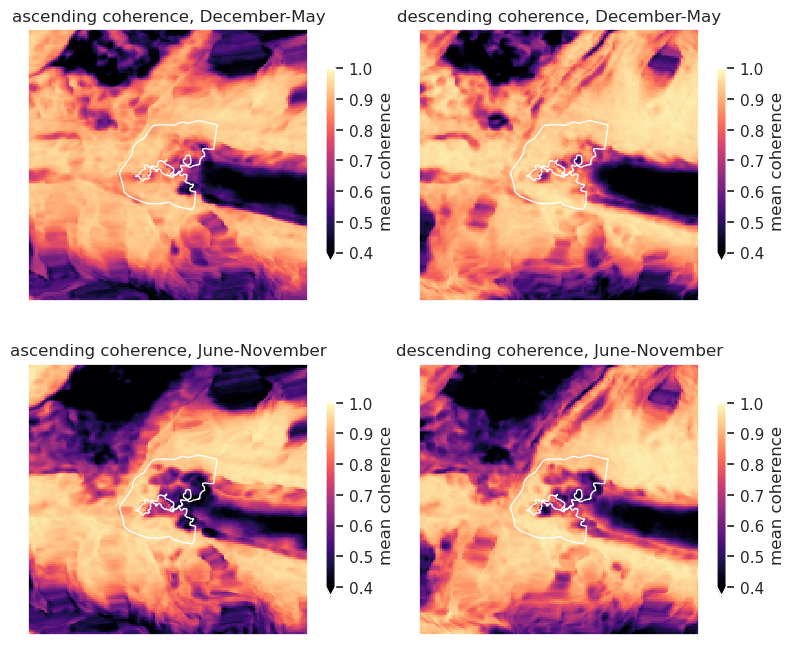

In [6]:
## plot mean warm-season and cold-season coherence for 12-day pairs

# isolate 12-day pairs
asc_corr_ds_12day = asc_corr_ds.where(asc_corr_ds.t_baseline.dt.days == 12 , drop=True)
des_corr_ds_12day = des_corr_ds.where(des_corr_ds.t_baseline.dt.days == 12 , drop=True)

# warm-season and cold-season coherence
asc_corr_summer_ds = asc_corr_ds_12day.where((asc_corr_ds_12day.start_date.dt.dayofyear > 152) & (asc_corr_ds_12day.end_date.dt.dayofyear < 334), drop=True)
des_corr_summer_ds = des_corr_ds_12day.where((des_corr_ds_12day.start_date.dt.dayofyear > 152) & (des_corr_ds_12day.end_date.dt.dayofyear < 334), drop=True)

asc_corr_winter_ds = asc_corr_ds_12day.where((asc_corr_ds_12day.start_date.dt.dayofyear < 152) | (asc_corr_ds_12day.end_date.dt.dayofyear > 334), drop=True)
des_corr_winter_ds = des_corr_ds_12day.where((des_corr_ds_12day.start_date.dt.dayofyear < 152) | (des_corr_ds_12day.end_date.dt.dayofyear > 334), drop=True)

# set up figure and axes
f, ax = plt.subplots(2, 2, figsize=(8, 7), sharex=True, sharey=True)

# helper function to plot a single panel
def plot_panel(data, axis, title):
    data.mean(dim='dates').plot.imshow(
        ax=axis,
        vmin=0.4,
        vmax=1,
        cmap='magma',
        cbar_kwargs={'label': 'mean coherence', 'shrink': 0.6}
    )
    dam_gdf.plot(ax=axis, edgecolor='white', facecolor='none')
    axis.set_title(title)
    axis.set_aspect('equal')
    padding = 4000
    axis.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
    axis.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel('')
    axis.set_ylabel('')

# list of datasets, axes, and titles
panels = [
    (asc_corr_winter_ds, ax[0, 0], 'ascending coherence, December-May'),
    (des_corr_winter_ds, ax[0, 1], 'descending coherence, December-May'),
    (asc_corr_summer_ds, ax[1, 0], 'ascending coherence, June-November'),
    (des_corr_summer_ds, ax[1, 1], 'descending coherence, June-November'),
]

# plot all panels
for ds, axis, title in panels:
    plot_panel(ds[f'corr_{dam_name}'], axis, title)

f.tight_layout()

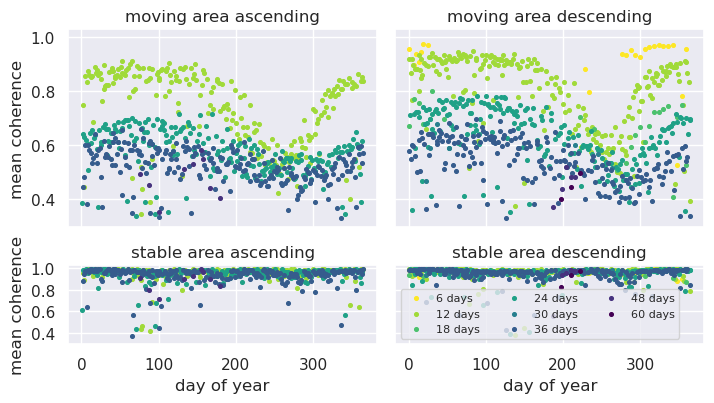

In [7]:
# plot seasonal coherence change over moving and stable area

# clip datasets to moving polygon
asc_dam_corr_ds = asc_corr_ds.rio.clip(moving_gdf.geometry.values, crs=moving_gdf.crs, drop=True)
asc_dam_corr_ds = asc_dam_corr_ds.assign_coords(middle_date = ('dates', (asc_dam_corr_ds.t_baseline/2+asc_dam_corr_ds.start_date).data))

des_dam_corr_ds = des_corr_ds.rio.clip(moving_gdf.geometry.values, crs=moving_gdf.crs, drop=True)
des_dam_corr_ds = des_dam_corr_ds.assign_coords(middle_date = ('dates', (des_dam_corr_ds.t_baseline/2+des_dam_corr_ds.start_date).data))

# clip datasets to stable polygon
asc_stable_corr_ds = asc_corr_ds.rio.clip(stable_gdf.geometry.values, crs=stable_gdf.crs, drop=True)
asc_stable_corr_ds = asc_stable_corr_ds.assign_coords(middle_date = ('dates', (asc_stable_corr_ds.t_baseline/2+asc_stable_corr_ds.start_date).data))

des_stable_corr_ds = des_corr_ds.rio.clip(stable_gdf.geometry.values, crs=stable_gdf.crs, drop=True)
des_stable_corr_ds = des_stable_corr_ds.assign_coords(middle_date = ('dates', (des_stable_corr_ds.t_baseline/2+des_stable_corr_ds.start_date).data))

t_baselines = np.union1d(des_dam_corr_ds.t_baseline.dt.days.values, asc_dam_corr_ds.t_baseline.dt.days.values)

# plot seasonal changes in coherence 
colors = plt.cm.viridis_r(np.linspace(0, 1, len(t_baselines)))

f, ax = plt.subplots(2, 2, figsize=(7.5, 4.2), sharex=True, sharey=True, gridspec_kw={'height_ratios': [2.5, 1]})
for i, days in enumerate(t_baselines):       
        
        ax[0, 0].scatter(asc_dam_corr_ds.middle_date[asc_dam_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      asc_dam_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[asc_dam_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')
        ax[0, 0].tick_params(left=False)

        ax[0, 1].scatter(des_dam_corr_ds.middle_date[des_dam_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      des_dam_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[des_dam_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')
        ax[0, 1].tick_params(left=False)

        ax[1, 0].scatter(asc_stable_corr_ds.middle_date[asc_stable_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      asc_stable_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[asc_stable_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')

        ax[1, 1].scatter(des_stable_corr_ds.middle_date[des_stable_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      des_stable_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[des_stable_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')

        ax[0, 0].set_ylabel('mean coherence')
        ax[1, 0].set_ylabel('mean coherence')
        ax[1, 0].set_xlabel('day of year')
        ax[1, 1].set_xlabel('day of year')
        ax[0, 0].set_title('moving area ascending')
        ax[0, 1].set_title('moving area descending')
        ax[1, 0].set_title('stable area ascending')
        ax[1, 1].set_title('stable area descending')
        ax[1, 1].legend(loc='lower left', fontsize=8, ncol=3)
  
f.tight_layout()

(3085224.5274983225, 3087199.4173047645)

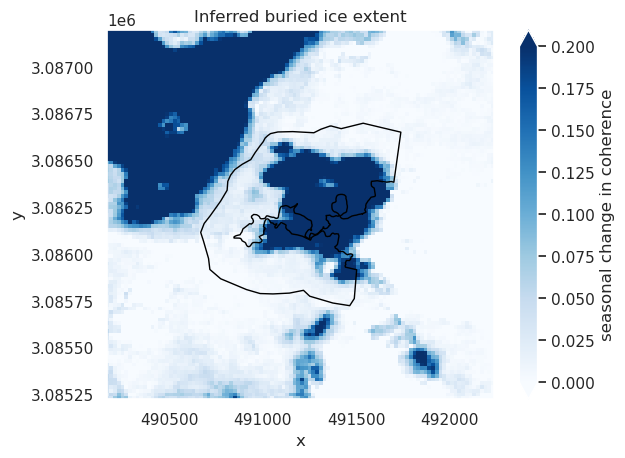

In [9]:
## buried ice extent

# low-coherence period 
asc_lowcorr_ds = asc_corr_ds_12day.where((asc_corr_ds_12day.start_date.dt.dayofyear > 220) & (asc_corr_ds_12day.end_date.dt.dayofyear < 280), drop=True)
des_lowcorr_ds = des_corr_ds_12day.where((des_corr_ds_12day.start_date.dt.dayofyear > 220) & (des_corr_ds_12day.end_date.dt.dayofyear < 280), drop=True)

# high-coherence period
asc_highcorr_ds = asc_corr_ds_12day.where(asc_corr_ds_12day.start_date.dt.dayofyear < 100, drop=True)
des_highcorr_ds = des_corr_ds_12day.where(des_corr_ds_12day.start_date.dt.dayofyear < 100, drop=True)

# combined coherence
asc_lowcorr_da = asc_lowcorr_ds.median(dim='dates').corr_imja
des_lowcorr_da = des_lowcorr_ds.median(dim='dates').corr_imja
lowcorr_da = (asc_lowcorr_da + des_lowcorr_da)/2

asc_highcorr_da = asc_highcorr_ds.median(dim='dates').corr_imja
des_highcorr_da = des_highcorr_ds.median(dim='dates').corr_imja
highcorr_da = (asc_highcorr_da + des_highcorr_da)/2

f, ax = plt.subplots()
(highcorr_da - lowcorr_da).plot(ax=ax, vmin=0, vmax=0.2, cmap='Blues', cbar_kwargs={'label': 'seasonal change in coherence'})
dam_gdf.plot(ax=ax, edgecolor='black', facecolor='none')
ax.set_title('Inferred buried ice extent')
padding=4500
ax.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
ax.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)

## Explore moraine dam displacement time series

In [10]:
ts_ds = xr.open_dataset('data_release/imja_cumulative_displacement_ts.nc')

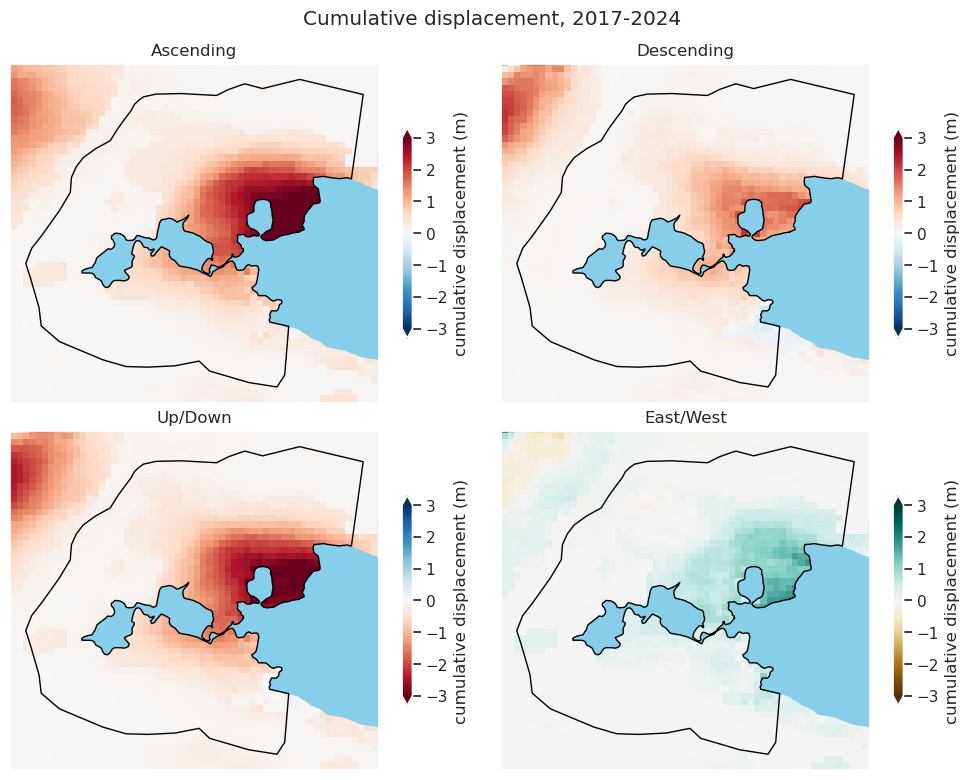

In [30]:
## plot cumulative displacement

f, ax = plt.subplots(2, 2, figsize=(10, 8))

# helper function to plot a single panel
def plot_panel(data, axis, title, cmap):
    data.plot.imshow(
        ax=axis,
        vmin=-3,
        vmax=3,
        cmap=cmap,
        cbar_kwargs={'label': 'cumulative displacement (m)', 'shrink': 0.6}
    )
    water_gdf.plot(ax=axis, edgecolor='none', facecolor='skyblue')
    dam_gdf.plot(ax=axis, edgecolor='black', facecolor='none')
    axis.set_title(title)
    axis.set_aspect('equal')
    padding = 4950
    axis.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
    axis.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel('')
    axis.set_ylabel('')

# list of datasets, axes, and titles
panels = [
    (ts_ds.asc_displacement.isel(time=-1), ax[0, 0], 'Ascending', 'RdBu_r'),
    (ts_ds.des_displacement.isel(time=-1), ax[0, 1], 'Descending', 'RdBu_r'),
    (ts_ds.vertical_displacement.isel(time=-1), ax[1, 0], 'Up/Down', 'RdBu'),
    (ts_ds.horizontal_displacement.isel(time=-1), ax[1, 1], 'East/West', 'BrBG'),
]

# plot all panels
for da, axis, title, cmap in panels:
    plot_panel(da, axis, title, cmap)

f.suptitle('Cumulative displacement, 2017-2024')
f.tight_layout()

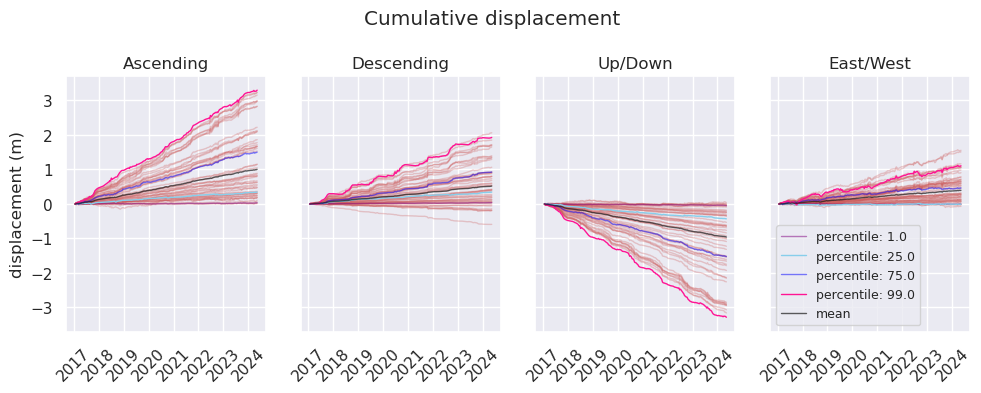

In [44]:
## Plot cumulative displaceement time series over the moving area
moving_ts = ts_ds.rio.clip(moving_gdf.geometry, drop=True)

percentiles = [0.01, 0.25, 0.75, 0.99] # pixels to highlight
x_list = []
y_list = []
for percentile in percentiles:
    cum_da = moving_ts.asc_displacement.isel(time=-1)
    perc_value = cum_da.quantile(percentile).item()
    abs_diff = np.abs(cum_da - perc_value)
    abs_diff = abs_diff.where(~np.isnan(abs_diff), np.inf)
    min_index = np.unravel_index(np.argmin(abs_diff.values), cum_da.shape)
    x_list.append(min_index[1])
    y_list.append(min_index[0])

points = [[x, y_list[i]] for i, x in enumerate(x_list)]

# all plots for fig
f, ax = plt.subplots(1, 4, figsize=(10,4), sharex=True, sharey=True)

# plot random pixels in moving area
sample=0
xy_list = []
# take n sample pixels
while sample < 50:
    x = np.random.choice(moving_ts.x)
    y = np.random.choice(moving_ts.y)
    # make sure pixel is valid
    if np.all(~np.isnan(moving_ts.asc_displacement.sel(x=x, y=y))):
        # sample without replacement
        if [x, y] not in xy_list:
            (moving_ts.asc_displacement.sel(x=x, y=y)*1).plot(ax=ax[0], c='indianred', linewidth=1, alpha=0.3)
            (moving_ts.des_displacement.sel(x=x, y=y)*1).plot(ax=ax[1], c='indianred', linewidth=1, alpha=0.3)
            (moving_ts.vertical_displacement.sel(x=x, y=y)*1).plot(ax=ax[2], c='indianred', linewidth=1, alpha=0.3)
            (moving_ts.horizontal_displacement.sel(x=x, y=y)*1).plot(ax=ax[3], c='indianred', linewidth=1, alpha=0.3)
            sample+=1 # increment sample
            xy_list.append([x, y]) # add pixel to list

# plot pixels corresponding to percentiles
colors = ['purple', 'skyblue', 'blue', 'deeppink']
alphas = [0.5, 1, 0.5, 1]
for i, point in enumerate(points):
    x, y = point
    moving_ts.asc_displacement.isel(x=x, y=y).plot(ax=ax[0], c=colors[i], linewidth=1, alpha=alphas[i])
    moving_ts.des_displacement.isel(x=x, y=y).plot(ax=ax[1], c=colors[i], linewidth=1, alpha=alphas[i])
    moving_ts.vertical_displacement.isel(x=x, y=y).plot(ax=ax[2], c=colors[i], linewidth=1, alpha=alphas[i])
    moving_ts.horizontal_displacement.isel(x=x, y=y).plot(ax=ax[3], c=colors[i], linewidth=1, alpha=alphas[i], label=f'percentile: {percentiles[i]*100}')

# plot means
(moving_ts.asc_displacement.mean(dim=('x', 'y'))*1).plot(ax=ax[0], c='k', linewidth=1, alpha=0.7)
(moving_ts.des_displacement.mean(dim=('x', 'y'))*1).plot(ax=ax[1], c='k', linewidth=1, alpha=0.7)
(moving_ts.vertical_displacement.mean(dim=('x', 'y'))*1).plot(ax=ax[2], c='k', linewidth=1, alpha=0.7)
(moving_ts.horizontal_displacement.mean(dim=('x', 'y'))*1).plot(ax=ax[3], c='k', linewidth=1, alpha=0.7, label='mean')

ax[0].set_title('Ascending')
ax[0].set_ylim(-3.7, 3.7)
#ax[0].set_ylim(-0.3, 3.4)
ax[0].set_ylabel('displacement (m)')
ax[0].set_xlabel('')
ax[0].tick_params('x', labelrotation=45)
ax[1].set_title('Descending')
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].tick_params('x', labelrotation=45)
ax[2].set_title('Up/Down')
ax[2].set_ylabel('')
ax[2].set_xlabel('')
ax[2].tick_params('x', labelrotation=45)
ax[3].set_title('East/West')
ax[3].set_ylabel('')
ax[3].set_xlabel('')
ax[3].tick_params('x', labelrotation=45)
ax[3].legend(loc='lower left', fontsize=9)
f.suptitle('Cumulative displacement')
f.tight_layout()

## Explore moraine dam velocity

In [55]:
# calculate velocity
ts_ds['vertical_velocity'] = ts_ds.vertical_displacement.differentiate(coord='time', edge_order=1, datetime_unit='D')*365.25
ts_ds['horizontal_velocity'] = ts_ds.horizontal_displacement.differentiate(coord='time', edge_order=1, datetime_unit='D')*365.25

In [56]:
median_monthly_ds = ts_ds.groupby(ts_ds.time.dt.month).median()

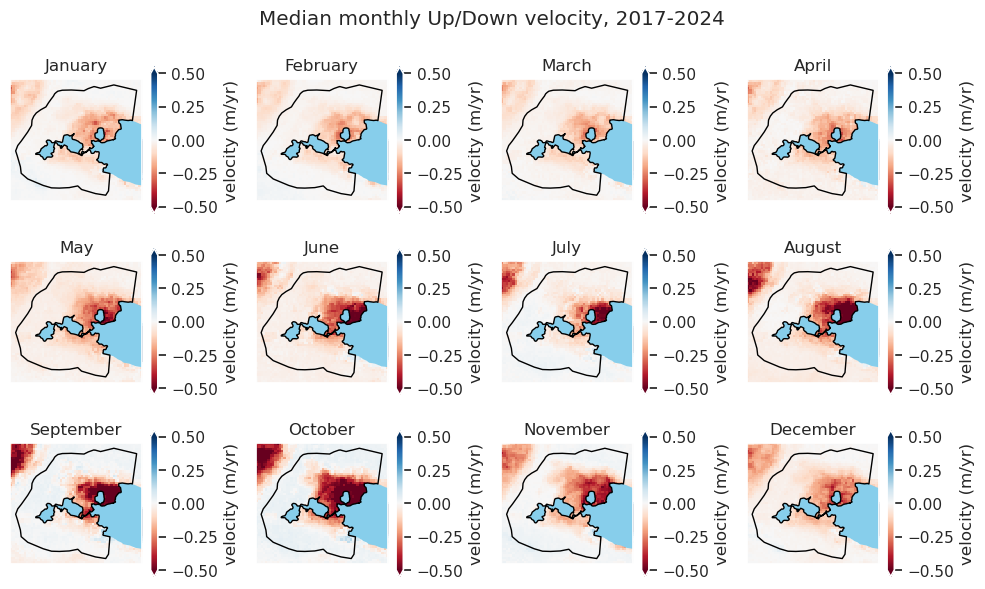

In [73]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
padding = 4950
f, axs = plt.subplots(3, 4, figsize=(10, 6))
for i, month in enumerate(months):
    ax = axs[i // 4, i % 4]
    median_monthly_ds.vertical_velocity.isel(month=i).plot.imshow(ax=ax, vmin=-0.5, vmax=0.5, cmap='RdBu', cbar_kwargs={'label': 'velocity (m/yr)'})
    water_gdf.plot(ax=ax, edgecolor='none', facecolor='skyblue')
    dam_gdf.plot(ax=ax, edgecolor='black', facecolor='none')
    ax.set_title(month)
    ax.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
    ax.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

f.suptitle('Median monthly Up/Down velocity, 2017-2024')
f.tight_layout()

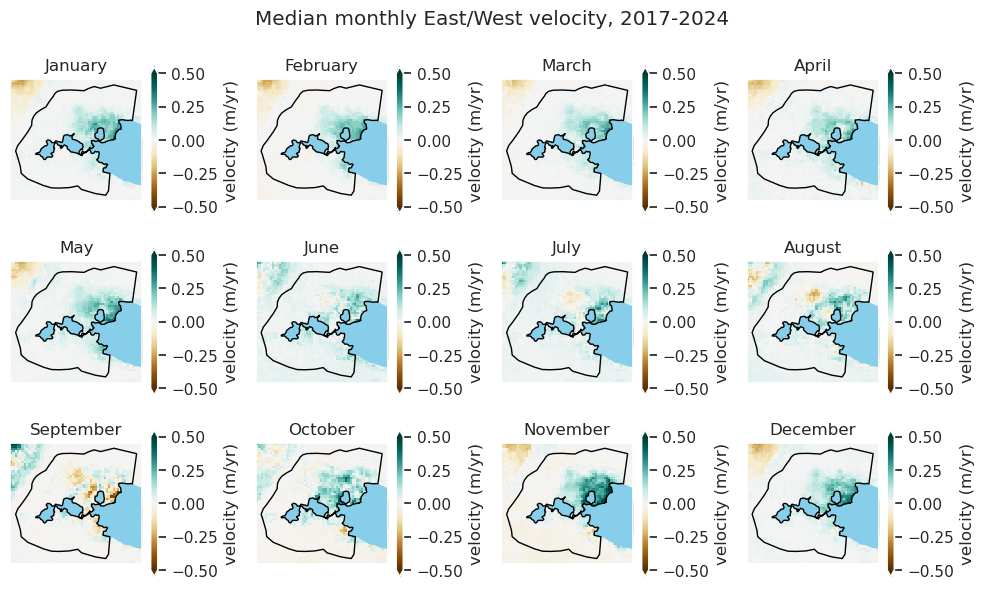

In [74]:
f, axs = plt.subplots(3, 4, figsize=(10, 6))
for i, month in enumerate(months):
    ax = axs[i // 4, i % 4]
    median_monthly_ds.horizontal_velocity.isel(month=i).plot.imshow(ax=ax, vmin=-0.5, vmax=0.5, cmap='BrBG', cbar_kwargs={'label': 'velocity (m/yr)'})
    water_gdf.plot(ax=ax, edgecolor='none', facecolor='skyblue')
    dam_gdf.plot(ax=ax, edgecolor='black', facecolor='none')
    ax.set_title(month)
    ax.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
    ax.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

f.suptitle('Median monthly East/West velocity, 2017-2024')
f.tight_layout()

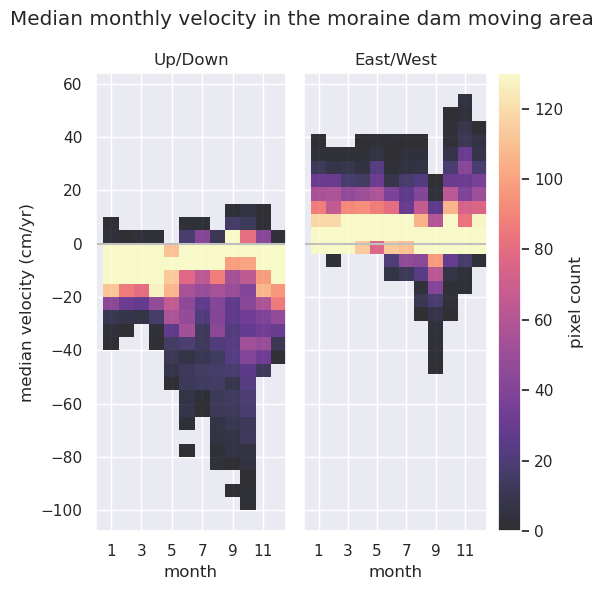

In [87]:
median_monthly_moving_ds = median_monthly_ds.rio.clip(moving_gdf.geometry, drop=True)
ones = xr.ones_like(median_monthly_moving_ds.vertical_velocity)
months_broadcast = ones*median_monthly_moving_ds.month

f, ax = plt.subplots(1, 2, figsize=(6, 6), sharex=True, sharey=True, gridspec_kw={'width_ratios': [1, 1.2]})
ax[0].axhline(y=0, c='silver', alpha=1)
ax[1].axhline(y=0, c='silver', alpha=1)
sns.histplot(ax=ax[0], x=months_broadcast.values.flatten(), y = median_monthly_moving_ds.vertical_velocity.values.flatten()*100, cbar=False, discrete=(True, False), binwidth=5, vmax=130, cmap='magma', alpha=0.8, cbar_kws={'label':'pixel count', 'orientation':'horizontal'})
sns.histplot(ax=ax[1], x=months_broadcast.values.flatten(), y = median_monthly_moving_ds.horizontal_velocity.values.flatten()*100, cbar=True, discrete=(True, False), binwidth=5, vmax=130, cmap='magma', alpha=0.8, cbar_kws={'label':'pixel count'})
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
ax[0].set_xticks([1, 3, 5, 7, 9, 11 ])
ax[1].set_xticks([1, 3, 5, 7, 9, 11 ])
ax[0].set_xlim(0, 12.5)
ax[1].set_xlim(0, 12.5)
ax[0].set_ylabel('median velocity (cm/yr)')
ax[1].set_ylabel('median velocity (cm/yr)')
ax[0].tick_params(left=False, right=False)
ax[1].tick_params(left=False, right=False)
ax[0].set_xlabel('month')
ax[1].set_xlabel('month')
ax[0].set_title('Up/Down')
ax[1].set_title('East/West')
f.suptitle('Median monthly velocity in the moraine dam moving area')
# ax[1].set_ylim(-55, 65)
# ax[0].set_ylim(-103, 20)

f.tight_layout()

## Explore 3D DEM validation dataset

In [99]:
dem_vx_da = rioxarray.open_rasterio('data_release/dem_vx.tif').squeeze()
dem_vx_da = dem_vx_da.where(dem_vx_da != -9999.)
dem_vx_da = dem_vx_da.rio.write_nodata(np.nan)

dem_vy_da = rioxarray.open_rasterio('data_release/dem_vy.tif').squeeze()
dem_vy_da = dem_vy_da.where(dem_vy_da != -9999.)
dem_vy_da = dem_vy_da.rio.write_nodata(np.nan)

dem_vz_da = rioxarray.open_rasterio('data_release/dem_vz.tif').squeeze()
dem_vz_da = dem_vz_da.where(dem_vz_da != -9999.)
dem_vz_da = dem_vz_da.rio.write_nodata(np.nan)

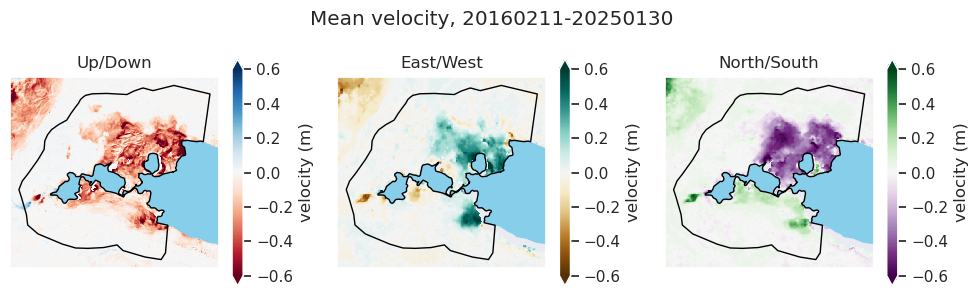

In [114]:
f, ax = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

# helper function to plot a single panel
def plot_panel(data, axis, title, cmap):
    data.plot.imshow(
        ax=axis,
        vmin=-0.6,
        vmax=0.6,
        cmap=cmap,
        cbar_kwargs={'label': 'velocity (m)'}
    )
    water_gdf.plot(ax=axis, edgecolor='none', facecolor='skyblue')
    dam_gdf.plot(ax=axis, edgecolor='black', facecolor='none')
    axis.set_title(title)
    axis.set_aspect('equal')
    padding = 4950
    axis.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
    axis.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel('')
    axis.set_ylabel('')

# list of datasets, axes, and titles
panels = [
    (dem_vz_da, ax[0], 'Up/Down', 'RdBu'),
    (dem_vx_da, ax[1], 'East/West', 'BrBG'),
    (dem_vy_da, ax[2], 'North/South', 'PRGn')
]

# plot all panels
for da, axis, title, cmap in panels:
    plot_panel(da, axis, title, cmap)

f.suptitle('Mean velocity, 20160211-20250130')
f.tight_layout()